In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load dataset
sold = pd.read_csv("CombinedSold_Residential.csv", low_memory=False)

# Preview
sold.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,...,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
1,SanDiego,SanDiego,NaN,False,NaN,NaN,False,759900.0,522107581,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
2,SanDiego,SanDiego,NaN,False,NaN,NaN,False,739900.0,510919001,mdarwich12@gmail.com,...,91950,NaN,NaN,NaN,CRMLS,CRMLS_SAND,NaN,NaN,NaN,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,92262,NaN,13504.0,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
4,Southland,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,91356,0.0,17873.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


Dataset Understanding

In [3]:
print("Number of rows and columns:", sold.shape)

Number of rows and columns: (386556, 84)


In [4]:
sold.columns

Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'ListingId', 'BathroomsTotalInteger', 'City', '

In [5]:
sold.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 386556 entries, 0 to 386555
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 338607 non-null  object 
 1   ListAgentAOR                  340373 non-null  object 
 2   Flooring                      248059 non-null  object 
 3   ViewYN                        353345 non-null  object 
 4   WaterfrontYN                  244 non-null     object 
 5   BasementYN                    7594 non-null    object 
 6   PoolPrivateYN                 352670 non-null  object 
 7   OriginalListPrice             385837 non-null  float64
 8   ListingKey                    386556 non-null  int64  
 9   ListAgentEmail                368591 non-null  object 
 10  CloseDate                     386556 non-null  object 
 11  ClosePrice                    386554 non-null  float64
 12  ListAgentFirstName            383599 non-nul

In [6]:
# Identify high-missing columns
missing_count = sold.isnull().sum()
missing_percent = (missing_count / len(sold)) * 100

missing_summary = pd.DataFrame({
    "MissingCount": missing_count,
    "MissingPercent": missing_percent
}).sort_values("MissingPercent", ascending=False)

missing_summary.head(20)

,MissingCount,MissingPercent
CoveredSpaces,386556,100.000000
MiddleOrJuniorSchoolDistrict,386556,100.000000
AboveGradeFinishedArea,386556,100.000000
FireplacesTotal,386556,100.000000
TaxYear,386556,100.000000
ElementarySchoolDistrict,386556,100.000000
BusinessType,386556,100.000000
TaxAnnualAmount,386556,100.000000
WaterfrontYN,386312,99.936878
BelowGradeFinishedArea,384337,99.425956


In [7]:
# Flag columns with more than 90% missing
high_missing_cols = missing_summary[missing_summary["MissingPercent"] > 90]
high_missing_cols

,MissingCount,MissingPercent
CoveredSpaces,386556,100.000000
MiddleOrJuniorSchoolDistrict,386556,100.000000
AboveGradeFinishedArea,386556,100.000000
FireplacesTotal,386556,100.000000
TaxYear,386556,100.000000
ElementarySchoolDistrict,386556,100.000000
BusinessType,386556,100.000000
TaxAnnualAmount,386556,100.000000
WaterfrontYN,386312,99.936878
BelowGradeFinishedArea,384337,99.425956


In [ ]:
# Separate market analysis fields from metadata fields
market_fields = [
    "ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
    "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt", "CountyOrParish",
    "PropertyType", "CloseDate", "ListingContractDate"
]

metadata_fields = [
    "ListingKey", "ListingKeyNumeric", "ListingId",
    "ListAgentEmail", "ListAgentFirstName", "ListAgentLastName",
    "BuyerAgentFirstName", "BuyerAgentLastName",
    "ListOfficeName", "BuyerOfficeName", "CoListOfficeName"
]

print("Market analysis fields:")
print(market_fields)

print("\nMetadata fields:")
print(metadata_fields)

Market analysis fields:
['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt', 'CountyOrParish', 'PropertyType', 'CloseDate', 'ListingContractDate']

Metadata fields:
['ListingKey', 'ListingKeyNumeric', 'ListingId', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName']


In [9]:
# Decide which column to drop & retain
core_fields = [
    "PropertyType", "ClosePrice", "ListPrice", "OriginalListPrice",
    "LivingArea", "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt", "CountyOrParish",
    "CloseDate", "ListingContractDate"
]

drop_candidates = [
    col for col in high_missing_cols.index
    if col not in core_fields
]

retain_candidates = [col for col in sold.columns if col not in drop_candidates]

print("Columns to consider dropping:")
print(drop_candidates)

print("\nNumber of columns to retain:", len(retain_candidates))

Columns to consider dropping:
['CoveredSpaces', 'MiddleOrJuniorSchoolDistrict', 'AboveGradeFinishedArea', 'FireplacesTotal', 'TaxYear', 'ElementarySchoolDistrict', 'BusinessType', 'TaxAnnualAmount', 'WaterfrontYN', 'BelowGradeFinishedArea', 'BasementYN', 'LotSizeDimensions', 'BuilderName', 'BuildingAreaTotal', 'OriginatingSystemName', 'OriginatingSystemSubName', 'CoBuyerAgentFirstName']

Number of columns to retain: 67


Numeric Distribution Review

In [12]:
numeric_cols = [
    "ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
    "LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt"
]

for col in numeric_cols:
    sold[col] = pd.to_numeric(sold[col], errors="coerce")


percentile_summary = sold[numeric_cols].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T
percentile_summary

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
ClosePrice,386554.0,1.187849e+06,5.966132e+06,0.0,203999.53,340000.00,415000.0000,575000.00,825000.0000,1.300000e+06,2068350.00,2.850000e+06,5550000.00,9.895000e+08
ListPrice,386556.0,1.140002e+06,1.353250e+06,525.0,215000.00,348475.00,419500.0000,579000.00,819000.0000,1.295000e+06,1999000.00,2.850000e+06,5695000.00,1.375000e+08
OriginalListPrice,385837.0,1.227317e+06,6.868697e+06,0.0,214308.00,349900.00,425000.0000,587000.00,828000.0000,1.299000e+06,2060000.00,2.899000e+06,5993200.00,1.390000e+09
LivingArea,386330.0,1.904652e+03,2.740069e+04,0.0,604.00,838.00,982.0000,1247.00,1640.0000,2.216000e+03,2974.00,3.556000e+03,5277.71,1.702132e+07
LotSizeAcres,356008.0,6.991103e+01,1.655884e+04,0.0,0.00,0.03,0.0617,0.12,0.1663,2.704000e-01,1.03,2.784900e+00,10.77,7.810698e+06
BedroomsTotal,386545.0,3.200026e+00,1.066730e+00,0.0,1.00,2.00,2.0000,3.00,3.0000,4.000000e+00,4.00,5.000000e+00,6.00,4.500000e+01
BathroomsTotalInteger,386487.0,2.531806e+00,1.136779e+00,0.0,1.00,1.00,1.0000,2.00,2.0000,3.000000e+00,4.00,4.000000e+00,6.00,1.750000e+02
DaysOnMarket,386556.0,3.675820e+01,5.292240e+01,-288.0,0.00,1.00,4.0000,8.00,18.0000,4.800000e+01,92.00,1.290000e+02,226.00,1.243000e+04
YearBuilt,386208.0,1.978486e+03,2.625715e+01,1776.0,1912.00,1930.00,1947.0000,1960.00,1979.0000,1.998000e+03,2015.00,2.022000e+03,2025.00,2.026000e+03


Visualizations

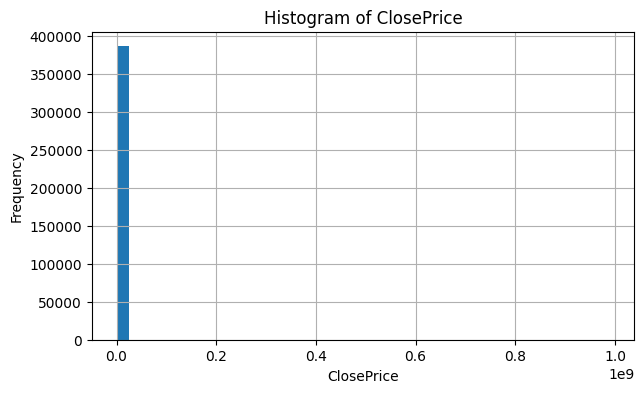

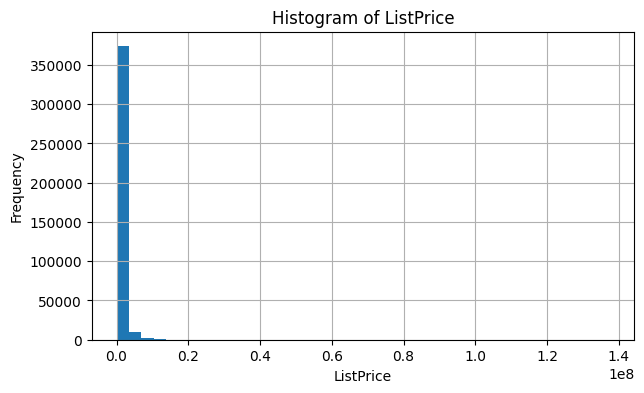

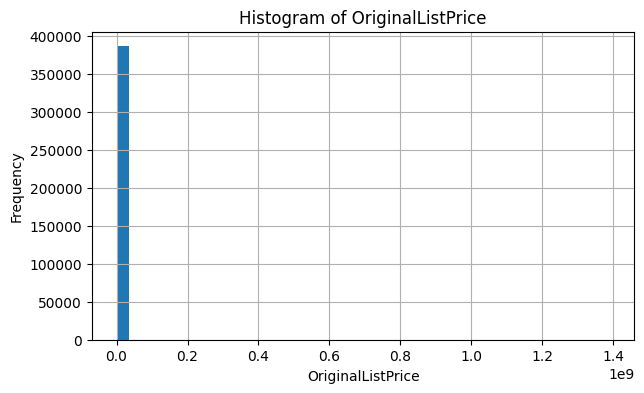

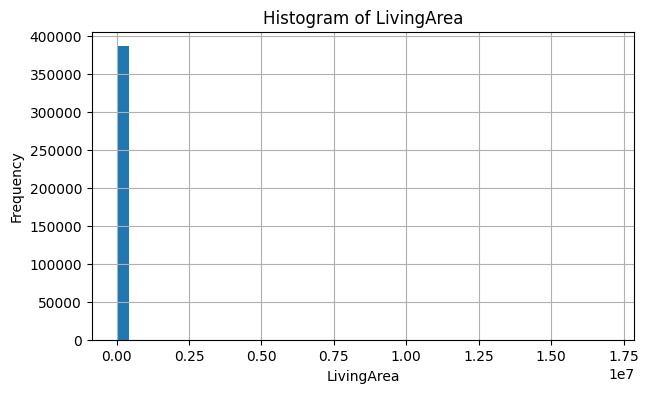

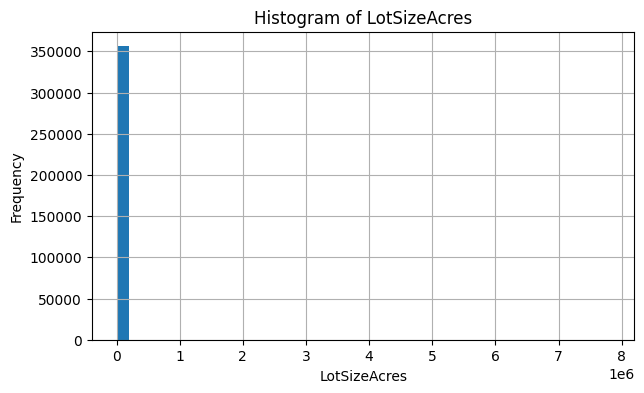

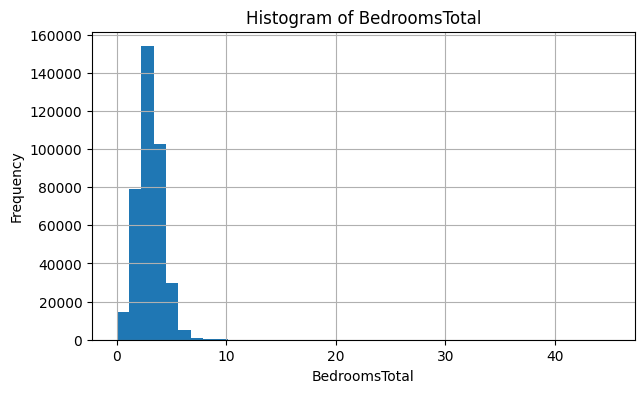

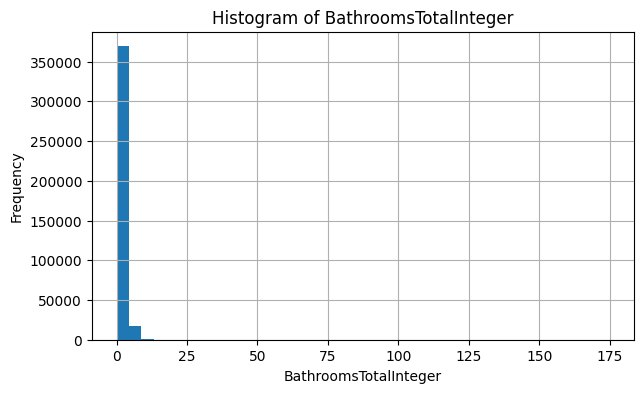

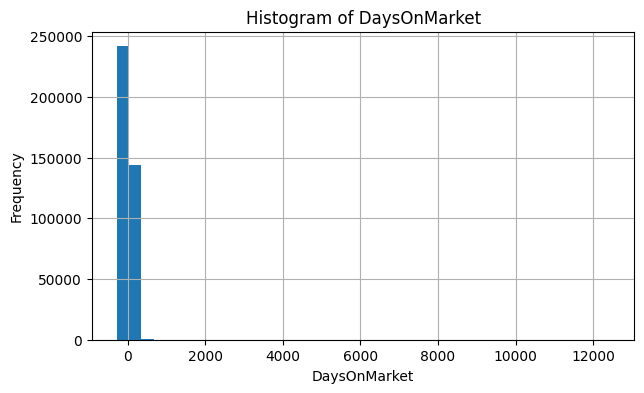

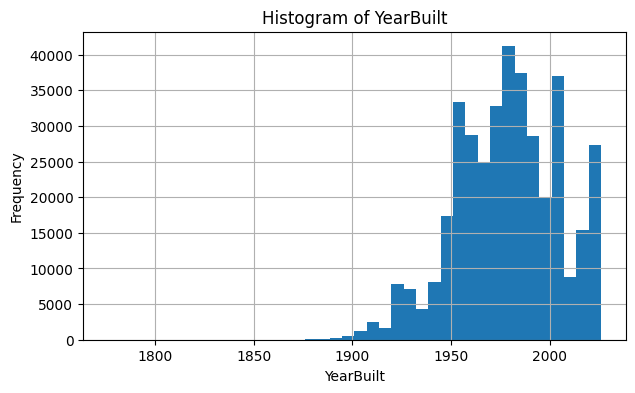

In [13]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sold[col].dropna().hist(bins=40)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

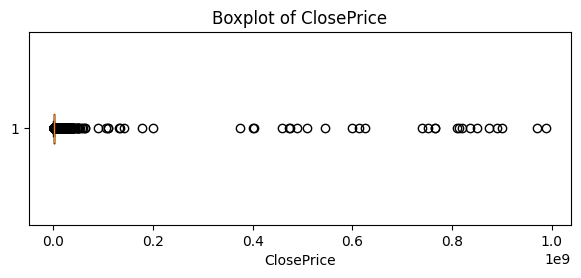

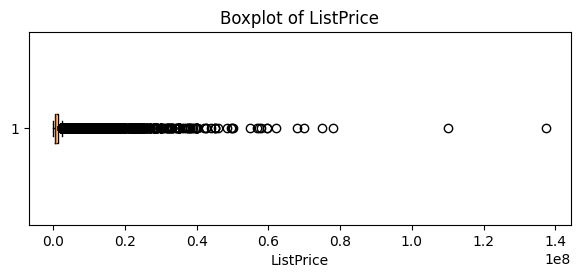

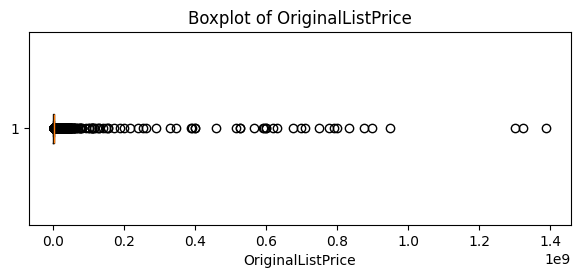

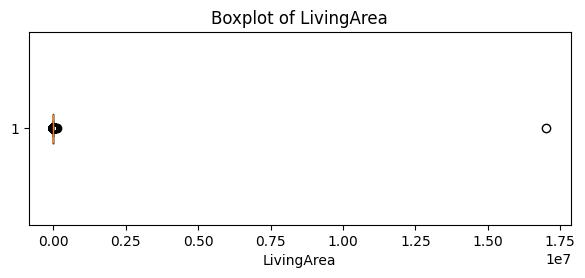

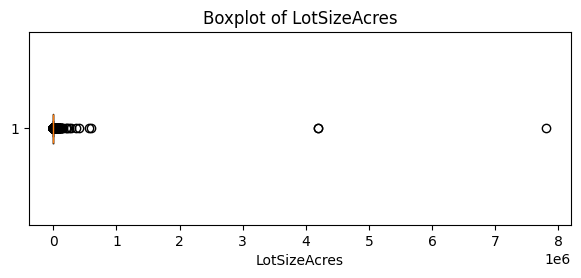

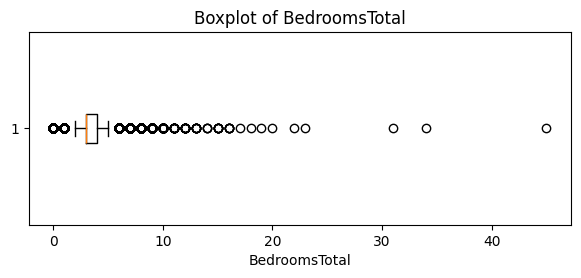

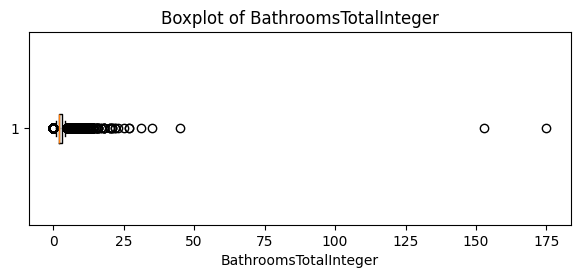

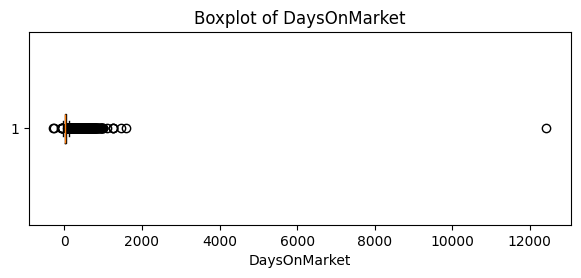

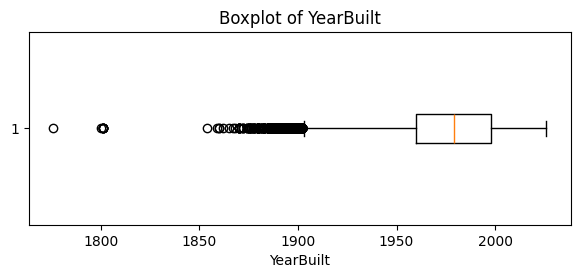

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(7, 2.5))
    plt.boxplot(sold[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [15]:
# Identify extreme outliers using IQR
outlier_summary = []

for col in numeric_cols:
    series = sold[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    
    outlier_summary.append({
        "Column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "LowerBound": lower_bound,
        "UpperBound": upper_bound,
        "OutlierCount": len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Column,Q1,Q3,IQR,LowerBound,UpperBound,OutlierCount
0,ClosePrice,575000.00,1.300000e+06,725000.0000,-512500.0000,2387500.000,28725
1,ListPrice,579000.00,1.295000e+06,716000.0000,-495000.0000,2369000.000,28963
2,OriginalListPrice,587000.00,1.299000e+06,712000.0000,-481000.0000,2367000.000,30097
3,LivingArea,1247.00,2.216000e+03,969.0000,-206.5000,3669.500,17061
4,LotSizeAcres,0.12,2.704000e-01,0.1504,-0.1056,0.496,55855
5,BedroomsTotal,3.00,4.000000e+00,1.0000,1.5000,5.500,21248
6,BathroomsTotalInteger,2.00,3.000000e+00,1.0000,0.5000,4.500,17668
7,DaysOnMarket,8.00,4.800000e+01,40.0000,-52.0000,108.000,28459
8,YearBuilt,1960.00,1.998000e+03,38.0000,1903.0000,2055.000,1010
